In [25]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

In [26]:
data_folder = r"/Users/hw4402/research/floodiq/climateiq_filecache_us/Atlanta-Atlanta_config/Rainfall_Data_1.txt"
data_name = "1_2.npy"
temporal_name = "temporal.npy"
dataset = "test"

In [27]:
geospatial_path = os.path.join(data_folder, dataset, "geospatial", data_name)
temporal_path = os.path.join(data_folder, temporal_name)
label_path = os.path.join(data_folder, dataset, "labels", data_name)

In [28]:
geospatial_data = np.load(geospatial_path)
label_data = np.load(label_path)
temporal_data = np.load(temporal_path)

In [29]:
print("Geospatial features dimension: ", geospatial_data.shape)
print("Label dimension: ", label_data.shape)
print("temporal features dimension :", temporal_data.shape)

Geospatial features dimension:  (1000, 1000, 9)
Label dimension:  (1000, 1000, 13)
temporal features dimension : (864,)


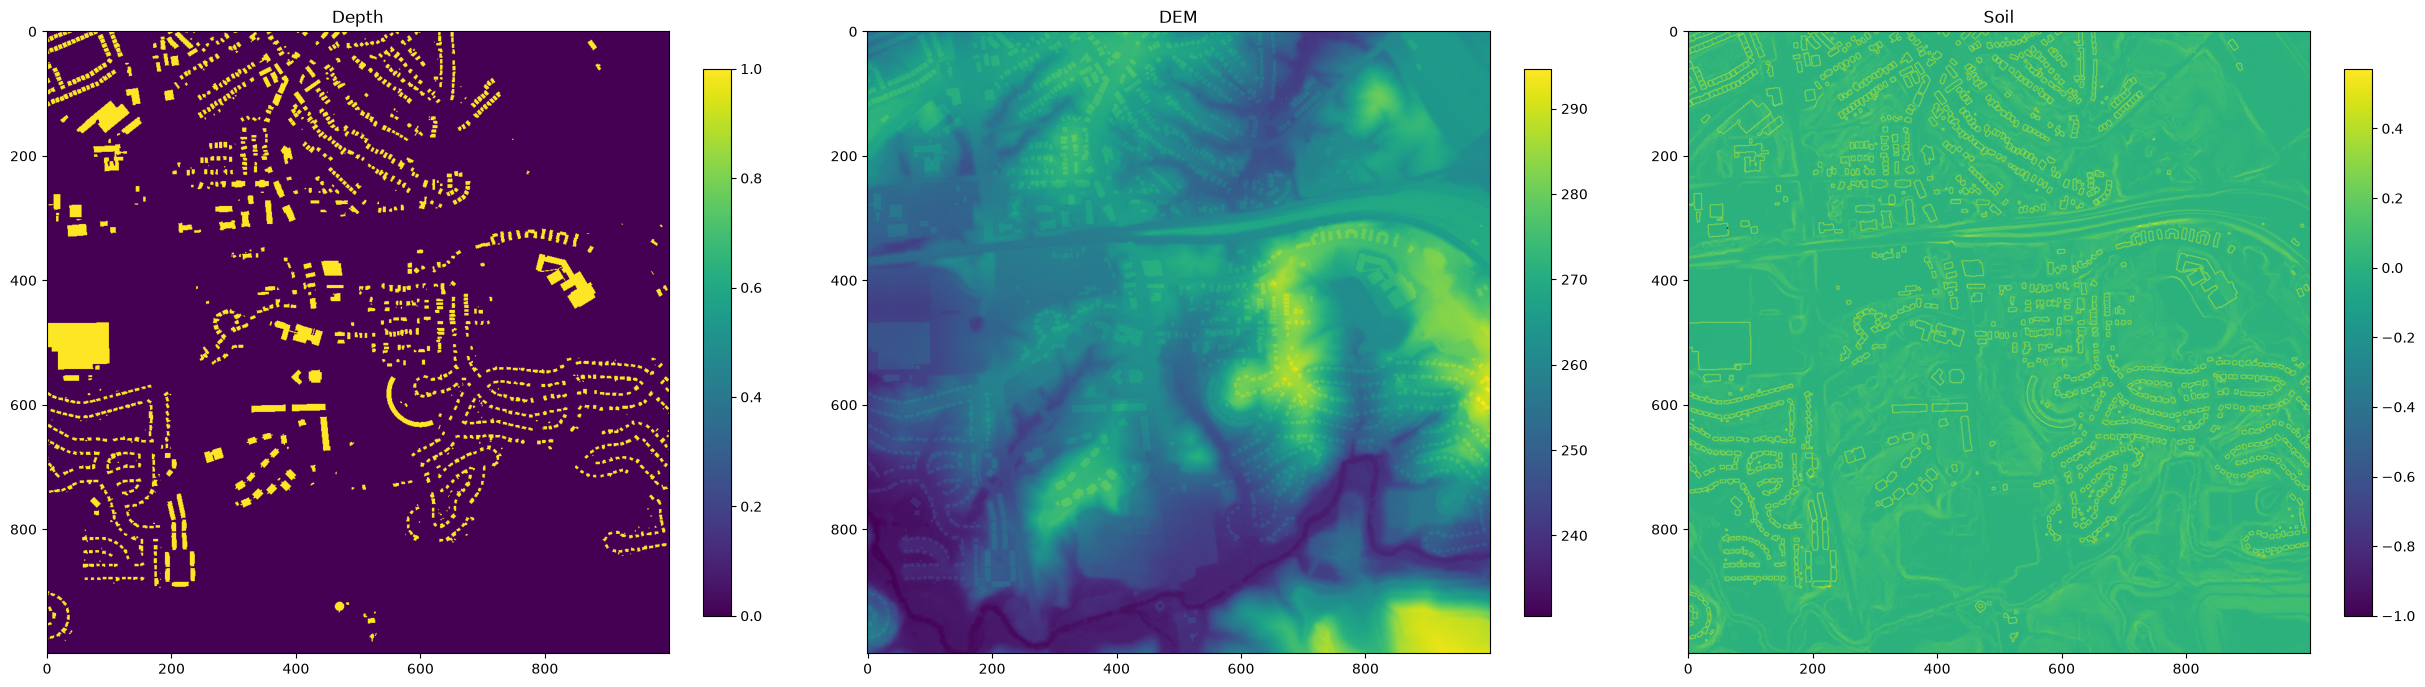

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(30, 10))
depth = axes[0].imshow(label_data[:, :, 1],  cmap="viridis", origin="upper")
dem_img = axes[1].imshow(geospatial_data[:, :, 0] * (332.31 - 165.7) + 165.7, cmap="viridis", origin="upper")
soil_img = axes[2].imshow(geospatial_data[:, :, 8], cmap="viridis", origin="upper")
depth = axes[0].imshow(geospatial_data[:, :, 2], cmap="viridis", origin="upper")

axes[0].set_title("Depth")
axes[1].set_title("DEM")
axes[2].set_title("Soil")

cbar1 = fig.colorbar(depth, ax=axes[0], fraction=0.04)
cbar2 = fig.colorbar(dem_img, ax=axes[1], fraction=0.04)
cbar3 = fig.colorbar(soil_img, ax=axes[2], fraction=0.04)

plt.show()

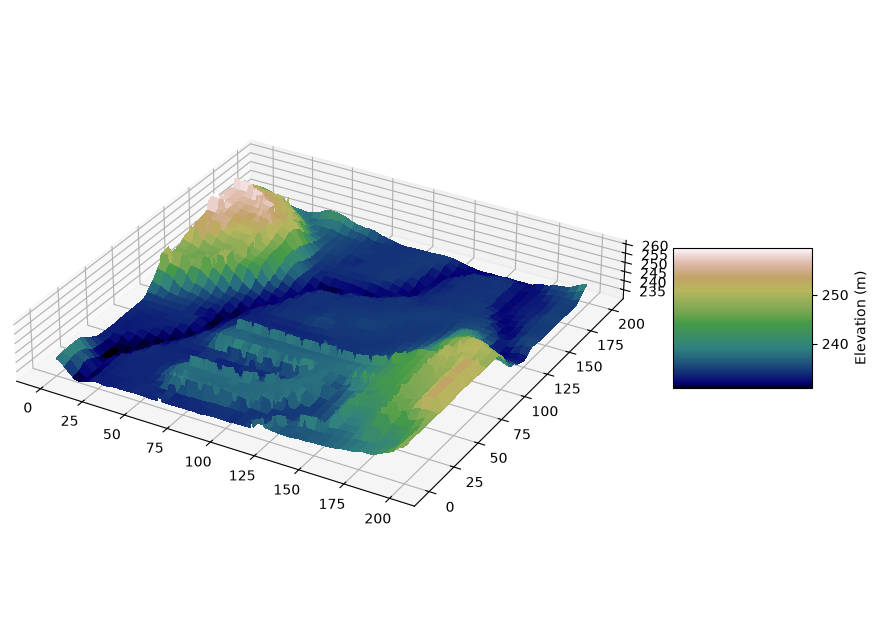

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Load or simulate your 1000x1000 DEM raster
# dem = rasterio.open('your_dem.tif').read(1)
dem = (geospatial_data[:, :, 0] * (332.31 - 165.7) + 165.7)[800:, 0:200]

# 2. Create grid coordinates matching the DEM dimensions
nrows, ncols = dem.shape
x = np.arange(ncols)
y = np.arange(nrows)
X, Y = np.meshgrid(x, y)

# 3. Initialize 3D Plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# 4. Plot surface with stride (e.g. stride=5 samples 1 out of every 5 points)
surf = ax.plot_surface(
    X, Y, dem, 
    cmap='gist_earth', 
    rstride=5, 
    cstride=5, 
    linewidth=0, 
    antialiased=False
)

# Set visual scaling relative to spatial extent
ax.set_box_aspect([ncols, nrows, np.ptp(dem)]) 

fig.colorbar(surf, ax=ax, shrink=0.5, aspect=1, label='Elevation (m)')
plt.show()

In [14]:
!pip install "keras<3.0.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 19.0 MB/s  0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 3.15.1
    Uninstalling keras-3.15.1:
      Successfully uninstalled keras-3.15.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
usl-models 0.0.0 requires google-cloud-aiplatform==1.43.0, which is not installed.
usl-models 0.0.0 requires seaborn==0.13.2, which is not installed.
usl-models 0.0.0 requires google-cloud-firestore==2.15.0, but you have google-cloud-firestore 2.34.0 which is incompatible.
usl-models 0.0.0 requires google-cloud-storage==2.15.0, but you have google-cloud-storage 3.16.0 which is incompatible.
usl-models 0.0.0 requires keras-tuner[bayesian]==1.4.7, but you have keras-tuner 1.4.8 which is incompatible.
usl-models 0.0.0 requires matplotlib==3.9.2, but you have matplotlib 3.11.2 which is incompatibl

In [15]:
# import os
# os.environ["TF_USE_LEGACY_KERAS"] = "1"

# import tensorflow as tf
# import tensorflow.keras as keras

from usl_models.flood_physical_ml.dataset import load_dataset_windowed_patches
import pathlib

In [17]:
FILECACHE_DIR = pathlib.Path("/Users/hw4402/research/floodiq/climateiq_filecache_us")
OUTPUT_DIR = pathlib.Path("/Users/hw4402/research/floodiq/climateiq_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
LOG_NAME = "09_23_VariedLength_6_steps_loss_no_peak"

PATCH_SIZE = 256
PATCH_STRIDE = 128
BATCH_SIZE = 8   # reverted from 6 — batch 4 had 16x better MAE (0.012 vs 0.197)
EPOCHS = 100  # ROUND 5 ABLATION — V3 loss only, validate before long run
N_FLOOD_MAPS = 5
M_RAINFALL = 6
N_FUTURE_STEPS = 6  # 13 → 0 windows (last_t = T - n_future = 13 - 13 = 0); 12 gives last_t=1 per chunk
DEPTH_CAP = 4.0  # metres — raised from 2.5; covers Atlanta peak (~4.4m capped at 4m)
                # Manhattan 5-7m ponding in closed canyons above this are outliers
DRY_TIMESTEP_FRACTION = 0.12  # calibrated from prior best run to avoid dry-step dominance

old_sims = [
    # Atlanta (3 scenarios)
    "Atlanta-Atlanta_config/Rainfall_Data_1.txt",
    "Atlanta-Atlanta_config/Rainfall_Data_2.txt",
    "Atlanta-Atlanta_config/Rainfall_Data_5.txt",
    # Phoenix SM (4 scenarios)
    "Phoenix_SM-PHX_SM/Rainfall_Data_1.txt",
    "Phoenix_SM-PHX_SM/Rainfall_Data_5.txt",
    "Phoenix_SM-PHX_SM/Rainfall_Data_15.txt",
    "Phoenix_SM-PHX_SM/Rainfall_Data_16.txt",
    # Manhattan (8 scenarios; 7 and 15 reserved for test)
    "Manhattan-Manhattan_config/Rainfall_Data_1.txt",
    "Manhattan-Manhattan_config/Rainfall_Data_2.txt",
    "Manhattan-Manhattan_config/Rainfall_Data_5.txt",
    "Manhattan-Manhattan_config/Rainfall_Data_6.txt",
    "Manhattan-Manhattan_config/Rainfall_Data_10.txt",
    "Manhattan-Manhattan_config/Rainfall_Data_13.txt",
    "Manhattan-Manhattan_config/Rainfall_Data_16.txt",
    "Manhattan-Manhattan_config/Rainfall_Data_19.txt",
    # Phoenix PV (2 scenarios)
    "Phoenix_PV-PHX_PV/Rainfall_Data_1.txt",
    "Phoenix_PV-PHX_PV/Rainfall_Data_5.txt",]

# ── New cities (never seen by model) ─────────────────────────────────
new_sims = [
        # Denton TX (13 timesteps, 1 chunk each)
    "Denton_TX-Denton_config/Rainfall_Data_1.txt",
    "Denton_TX-Denton_config/Rainfall_Data_2.txt",
    "Denton_TX-Denton_config/Rainfall_Data_5.txt",
    # Lafayette LA (13 timesteps, 1 chunk each)
    "Lafayette_LA-Lafayette_config/Rainfall_Data_1.txt",
    "Lafayette_LA-Lafayette_config/Rainfall_Data_2.txt",
    "Lafayette_LA-Lafayette_config/Rainfall_Data_5.txt",
    # Boise ID (13 timesteps, 1 chunk each)
    "Boise_ID-Boise_config/Rainfall_Data_1.txt",
    "Boise_ID-Boise_config/Rainfall_Data_2.txt",
    "Boise_ID-Boise_config/Rainfall_Data_5.txt",
    # Navarre FL (13 timesteps, 1-2 chunks each)
    "Navarre_FL-Navarre_config/Rainfall_Data_1.txt",
    "Navarre_FL-Navarre_config/Rainfall_Data_2.txt",
    "Navarre_FL-Navarre_config/Rainfall_Data_5.txt",
    # New Orleans
    "New_Orleans-New_Orleans_config/Rainfall_Data_1.txt",
    "New_Orleans-New_Orleans_config/Rainfall_Data_2.txt",
    "New_Orleans-New_Orleans_config/Rainfall_Data_5.txt",]

# BASELINE TRAINING: Only old cities for clean comparison
# Filter to only existing sims
old_sims = [s for s in old_sims if (FILECACHE_DIR / s).exists()]
new_sims = [s for s in new_sims if (FILECACHE_DIR / s).exists()]
sim_names = old_sims + new_sims  # All cities — learning new flow channels
# print(f"BASELINE TRAINING: {len(sim_names)} old city simulations (batch_size={BATCH_SIZE})")
# for s in sim_names:
#     print(f"  {s}")

split = "train"

ds = load_dataset_windowed_patches(
    filecache_dir=FILECACHE_DIR,
    sim_names=sim_names,
    dataset_split="train",
    patch_size=PATCH_SIZE,
    stride=PATCH_STRIDE,
    batch_size=BATCH_SIZE,
    n_flood_maps=N_FLOOD_MAPS,
    m_rainfall=M_RAINFALL,
    max_patches_per_chunk=None,
    min_flood_fraction=0.12,    # ≥1% flooded pixels — excludes all-dry patches
    min_max_depth=0.05,         # lowered from 0.1 — include early onset patches
    min_label_max_depth=0.001,  # lowered from 0.01 — include very early flood onset
    n_future_steps=N_FUTURE_STEPS,
    dry_timestep_fraction=DRY_TIMESTEP_FRACTION if split == "train" else 0.0,
    shuffle=True,
    temporal_feature_version=2,
)

i = 0
for d in ds:
    print("printing the sample: ", i)
    geo = d[0]["geospatial"]
    temp = d[0]["temporal"]
    spatemp = d[0]["spatiotemporal"]
    print("geofeature shape is:", geo.shape)
    print("temporal feature shape is:", temp.shape)
    print("spatiotemporal feature shape is:", spatemp.shape)
    break

printing the sample:  0
geofeature shape is: (8, 256, 256, 12)
temporal feature shape is: (8, 6, 5, 6)
spatiotemporal feature shape is: (8, 5, 256, 256, 1)


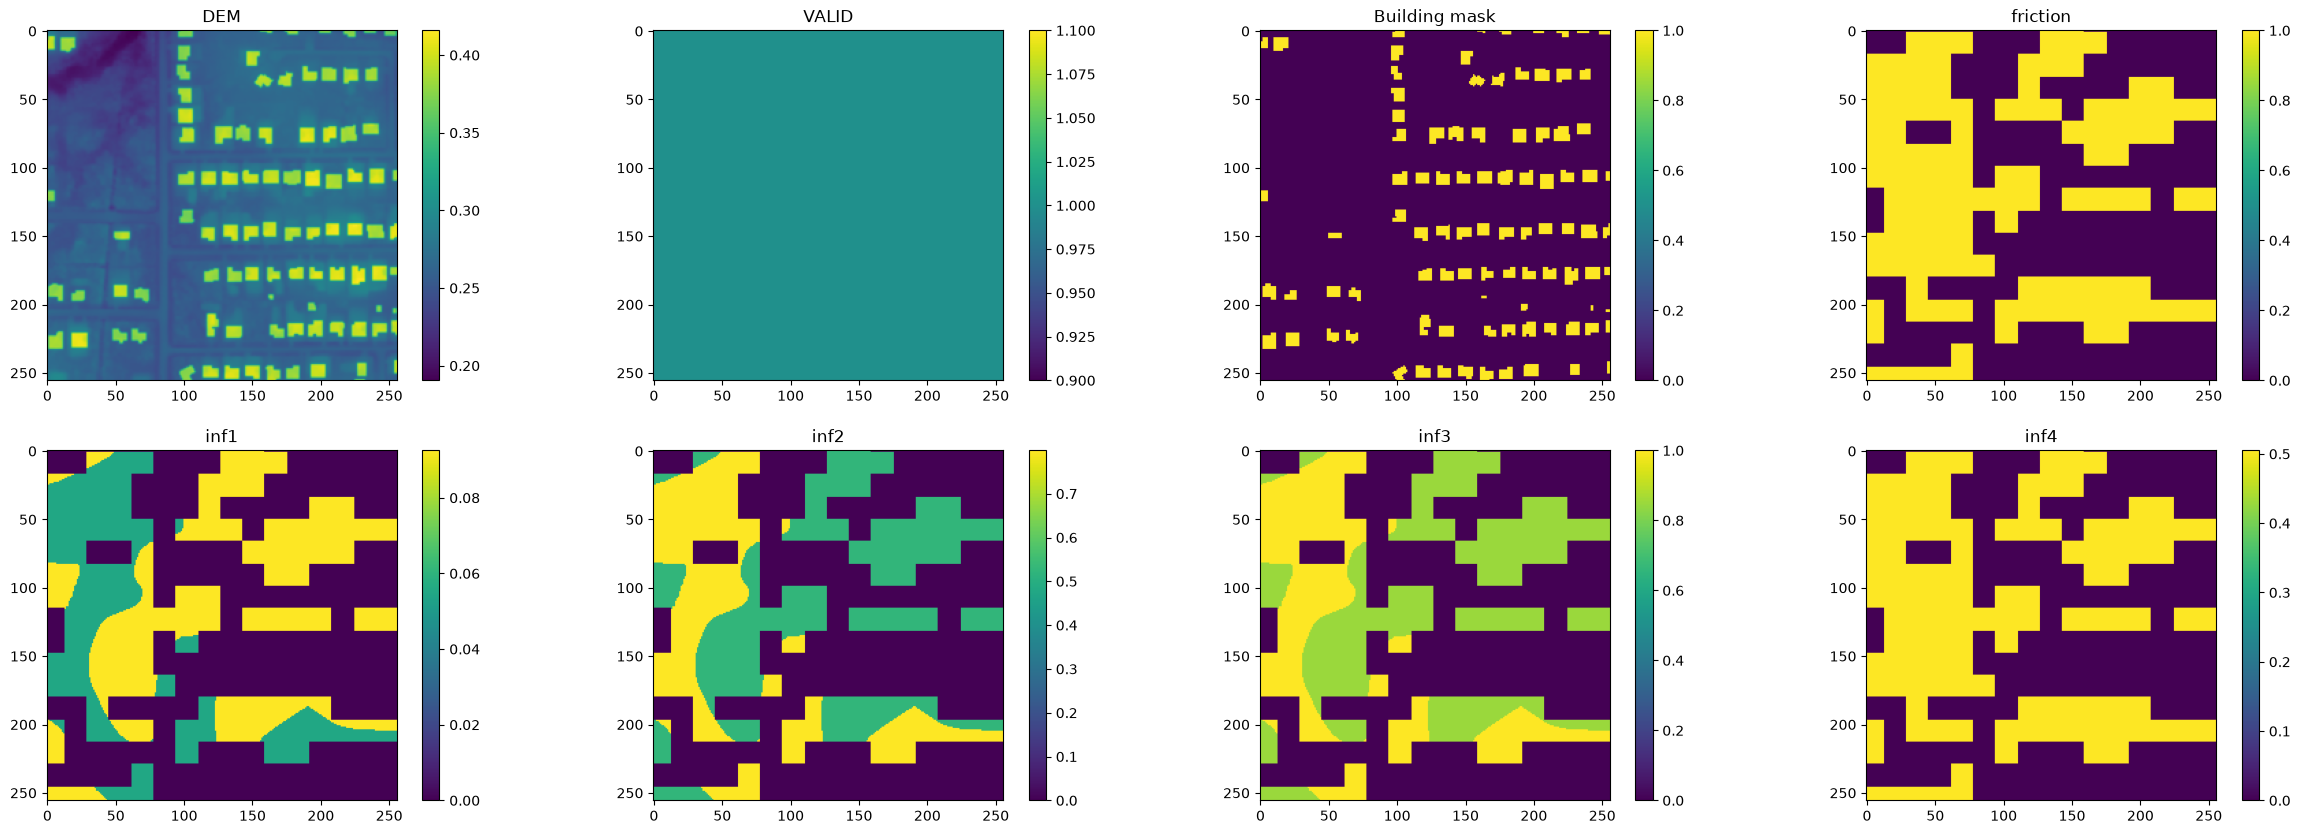

In [52]:
geospatial = d[0]["geospatial"]
dem = geospatial[..., 0][0]
valid_mask = geospatial[..., 1][0]
building = geospatial[..., 2][0]
friction = geospatial[..., 3][0]
inf1 = geospatial[..., 4][0]
inf2 = geospatial[..., 5][0]
inf3 = geospatial[..., 6][0]
inf4 = geospatial[..., 7][0]

fig, axes = plt.subplots(2, 4, figsize=(30, 10))
dem_img = axes[0, 0].imshow(dem,  cmap="viridis", origin="upper")
valid_img = axes[0, 1].imshow(valid_mask, cmap="viridis", origin="upper")
building_img = axes[0, 2].imshow(building, cmap="viridis", origin="upper")
friction_img = axes[0, 3].imshow(friction, cmap="viridis", origin="upper")
inf1_img = axes[1, 0].imshow(inf1, cmap="viridis", origin="upper")
inf2_img = axes[1, 1].imshow(inf2, cmap="viridis", origin="upper")
inf3_img = axes[1, 2].imshow(inf3, cmap="viridis", origin="upper")
inf4_img = axes[1, 3].imshow(inf4, cmap="viridis", origin="upper")

axes[0, 0].set_title("DEM")
axes[0, 1].set_title("VALID")
axes[0, 2].set_title("Building mask")
axes[0, 3].set_title("friction")
axes[1, 0].set_title("inf1")
axes[1, 1].set_title("inf2")
axes[1, 2].set_title("inf3")
axes[1, 3].set_title("inf4")

cbar1 = fig.colorbar(dem_img, ax=axes[0, 0], fraction=0.04)
cbar2 = fig.colorbar(valid_img, ax=axes[0, 1], fraction=0.04)
cbar3 = fig.colorbar(building_img, ax=axes[0, 2], fraction=0.04)
cbar4 = fig.colorbar(friction_img, ax=axes[0, 3], fraction=0.04)
cbar5 = fig.colorbar(inf1_img, ax=axes[1, 0], fraction=0.04)
cbar6 = fig.colorbar(inf2_img, ax=axes[1, 1], fraction=0.04)
cbar7 = fig.colorbar(inf3_img, ax=axes[1, 2], fraction=0.04)
cbar8 = fig.colorbar(inf4_img, ax=axes[1, 3], fraction=0.04)

plt.show()

In [102]:
input = d[0]
spatiotemporal = input["spatiotemporal"]
geospatial = input["geospatial"]
temporal = input["temporal"][:, 0]
T = spatiotemporal.shape[1]

water_depth = spatiotemporal # current depth [B, H, W, 1]
building = geospatial[..., 2:3] * 4 # Building mask [B, H, W, 1]
dem = geospatial[..., 0:1] # dem [B, H, W, 1]
friction_factor = geospatial[..., 3: 4] * 0.015 + 0.02
infiltration_factor = geospatial[..., 4:8]

dem = tf.tile(dem[:, tf.newaxis, ...], [1, T, 1, 1, 1])
building = tf.tile(building[:, tf.newaxis, ...], [1, T, 1, 1, 1])
friction_factor = tf.tile(friction_factor[:, tf.newaxis, ...], [1, T, 1, 1, 1])
infiltration_factor = tf.tile(infiltration_factor[:, tf.newaxis, ...], [1, T, 1, 1, 1])

In [103]:
print(water_depth.shape)
print(building.shape)
print(dem.shape)
print(friction_factor.shape)
print(infiltration_factor.shape)
print(temporal.shape)

(8, 5, 256, 256, 1)
(8, 5, 256, 256, 1)
(8, 5, 256, 256, 1)
(8, 5, 256, 256, 1)
(8, 5, 256, 256, 4)
(8, 5, 6)


In [104]:
water_level_feature = tf.concat([water_depth, building, dem], axis=-1)
friction_feature = tf.concat([water_depth, friction_factor], axis=-1)
infiltration_feature = tf.concat([water_depth, infiltration_factor], axis=-1)

In [105]:
print(water_level_feature.shape)
print(friction_feature.shape)
print(infiltration_feature.shape)

(8, 5, 256, 256, 3)
(8, 5, 256, 256, 2)
(8, 5, 256, 256, 5)


In [106]:
a = tf.constant([1, 2, 3])
b = tf.constant([4, 5, 6])

res = tf.stack([a, b], axis=-1)

print(res.numpy())

[[1 4]
 [2 5]
 [3 6]]


In [107]:
res

<tf.Tensor: shape=(3, 2), dtype=int32, numpy=
array([[1, 4],
       [2, 5],
       [3, 6]], dtype=int32)>

In [108]:
a

<tf.Tensor: shape=(3,), dtype=int32, numpy=array([1, 2, 3], dtype=int32)>

In [110]:
temporal[:, -1, -1]

<tf.Tensor: shape=(8,), dtype=float32, numpy=
array([0.00115875, 0.0023175 , 0.00463499, 0.00579374, 0.        ,
       0.00463499, 0.00347625, 0.        ], dtype=float32)>